✅ Loaded 614 unique toxic words/variants
Sample: ['w0r57 p14y3r', 'cope', 'c0w4rd r34lly', 'baliw', 'b4l1w', 'm4p4gm47445', 'h4y0p 741494', 'rage', 'b45ur4', 'p4kyu 741494', 'freak', 'pu74', 'sakim', 'coward really', 'w31rd0 r3411y']
Dictionary sample: ['w0r57 p14y3r', 'cope', 'c0w4rd r34lly', 'baliw', 'b4l1w', 'm4p4gm47445', 'h4y0p 741494', 'rage', 'b45ur4', 'p4kyu 741494']

Testing a few messages:
Raw: gago bakit mo
Norm: gago bakit mo
Flagged: True
---
Raw: b0b0 ka
Norm: bobo ka
Flagged: True
---
Raw: inutil ka talaga
Norm: inutil ka talaga
Flagged: False
---
Raw: good game
Norm: good game
Flagged: False
---


### ✅ Detection Results (Showing Normalization)

,Raw Message,Normalized,Expected,Detected,Stage,BM_Score,Matches
0,"gago, bakit mo binasag yung tower namin",gago bakit mo binasag yung tower namin,toxic,toxic,bm+ac,0.537,gago
1,"pre ang layo ng push mo, bobo",pre ang layo ng push mo bobo,toxic,toxic,bm+ac,0.537,bobo
2,"bakit ka nag-solo lord, tanga ka ba",bakit ka nag solo lord tanga ka ba,toxic,toxic,bm+ac,0.537,"tanga, tanga ka"
3,"ulol, sinong nagsabi sayo na mag-jungle ka",ulol sinong nagsabi sayo na mag jungle ka,toxic,toxic,bm+ac,0.537,ulol
4,"wala kang silbi sa team, inutil ka talaga",wala kang silbi sa team inutil ka talaga,toxic,clean,none,0.000,-
5,"tangina, bakit hindi ka nag-rotate sa mid",tangina bakit hindi ka nag rotate sa mid,toxic,toxic,bm+ac,0.725,tangina
6,"ang tarantado mong support, walang heal",ang tarantado mong support walang heal,toxic,clean,none,0.000,-
7,"report niyo itong feeder, gago talaga",report niyo itong feeder gago talaga,toxic,toxic,bm+ac,0.537,"feeder, gago, gago talaga"
8,"leche ka, bakit mo ginamit ult ko ng wala",leche ka bakit mo ginamit ult ko ng wala,toxic,clean,none,0.350,-
9,"sino ang nag-pick ng Franco, putang ina",sino ang nag pick ng franco putangina,toxic,toxic,bm+ac,0.843,"puta, putangina, tangina"


Pipeline detected 43/90 messages correctly (47.78%)


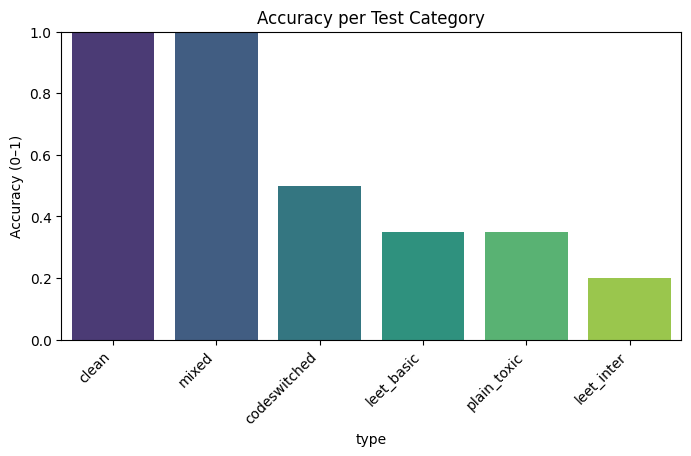

### ⚙️ Benchmark Results Preview

,Test_ID,Message_Type,Is_Toxic,Approach,Time_us,Memory_KB
0,1,plain_toxic,True,Boyer–Moore,1077.6,1.779297
1,1,plain_toxic,True,Aho–Corasick,223.5,12.951172
2,1,plain_toxic,True,Hybrid,578.0,1.646484
3,2,plain_toxic,True,Boyer–Moore,452.9,1.626953
4,2,plain_toxic,True,Aho–Corasick,183.8,9.826172


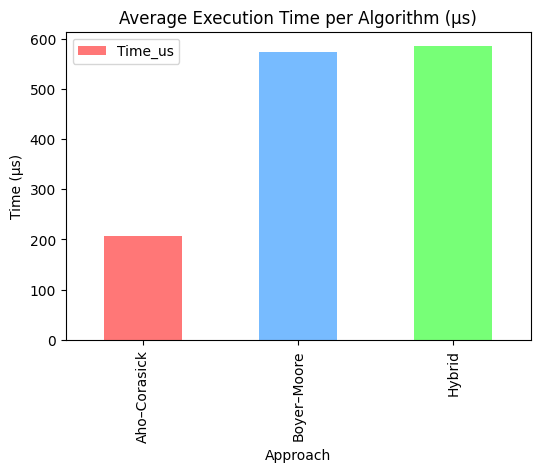

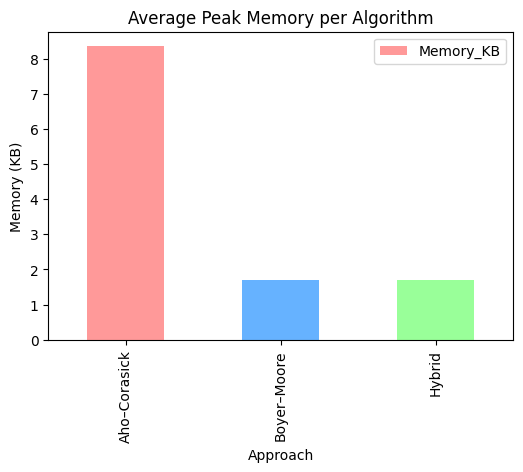

### 💬 Try your own message

Enter a message to test:  TNGINA KASI


✅ **Clean**

Original   : TNGINA KASI
Normalized : tngina kasi


Notebook completed successfully. ✅

In [1]:
# =============================================================================
# Toxic Language Detection — Hybrid Pipeline Notebook
# =============================================================================
# Must be placed inside: hybrid_pipeline-main/
# =============================================================================
import sys, os

# notebook.ipynb lives inside hybrid_pipeline-main/
# so we just add the current working directory directly
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), "experiments"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Pipeline imports
from test_cases import test_cases
from hybrid import HybridPipeline
from boyer_moore import boyer_moore_detect
from normalizer import normalize  # <--- IMPORTED YOUR NORMALIZER
from aho_corasick import (
    aho_corasick_scan_prebuilt,
    build_trie,
    build_failure_links,
)

# =============================================================================
# Load dictionary from dataset — FIXED
# =============================================================================
DATA_PATH = "data/dict_large.csv" 

# Read without assuming headers
df = pd.read_csv(DATA_PATH, header=None)

# The actual words are likely in column 0 or 1
words = []

# Try multiple columns that might contain words
for col in df.columns:
    col_data = df[col].dropna().astype(str).str.lower().str.strip()
    words.extend(col_data.tolist())

# Clean and deduplicate
dictionary = list(set([w for w in words if len(w) > 2 and not w.startswith('#') and not w[0].isdigit()]))

print(f"✅ Loaded {len(dictionary)} unique toxic words/variants")
print("Sample:", dictionary[:15])

# =============================================================================
# Quick validation

# =============================================================================
# Initialize Hybrid Pipeline
# =============================================================================
pipeline = HybridPipeline(dictionary)

print("Dictionary sample:", dictionary[:10])
print("\nTesting a few messages:")

test_msgs = ["gago bakit mo", "b0b0 ka", "inutil ka talaga", "good game"]

for m in test_msgs:
    norm = normalize(m)
    res = pipeline.process(m)
    print(f"Raw: {m}")
    print(f"Norm: {norm}")
    print(f"Flagged: {res['flagged']}")
    print("---")


# =============================================================================
# Run test cases through the pipeline (NOW SHOWING NORMALIZATION)
# =============================================================================
results = []

for tc in test_cases:
    raw_msg = tc["message"]
    normalized_msg = normalize(raw_msg)  # <--- APPLYING NORMALIZER TO SEE IT
    
    res = pipeline.process(raw_msg)
    
    results.append({
        "Raw Message": raw_msg,
        "Normalized": normalized_msg,     # <--- ADDED TO THE TABLE
        "Expected": tc["label"],
        "Detected": "toxic" if res["flagged"] else "clean",
        "Stage": res["stage_triggered"],
        "BM_Score": res.get("bm_score", 0),
        "Matches": ", ".join([m["pattern"] for m in res["matches"]]) if res["matches"] else "-",
    })

df_results = pd.DataFrame(results)
display(Markdown("### ✅ Detection Results (Showing Normalization)"))
# Show more rows so you can see the LeetSpeak translations!
display(df_results.head(15)) 

# =============================================================================
# Accuracy Summary
# =============================================================================
correct = (df_results["Detected"] == df_results["Expected"]).sum()
total = len(df_results)
accuracy = correct / total * 100

print(f"Pipeline detected {correct}/{total} messages correctly ({accuracy:.2f}%)")

# Add per-category accuracy barplot using seaborn
df_results["Correct"] = df_results["Detected"] == df_results["Expected"]
cat_acc = (
    pd.DataFrame(test_cases)
    .assign(Correct=df_results["Correct"])
    .groupby("type")["Correct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=cat_acc.index, y=cat_acc.values, hue=cat_acc.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.title("Accuracy per Test Category")
plt.ylabel("Accuracy (0–1)")
plt.ylim(0, 1)
plt.show()

# =============================================================================
# Benchmark Results (Execution Time + Memory)
# =============================================================================
CSV_PATH = "experiments/results/tables/benchmark_results.csv"

if os.path.exists(CSV_PATH):
    bench = pd.read_csv(CSV_PATH)
    display(Markdown("### ⚙️ Benchmark Results Preview"))
    display(bench.head())

    # Compute averages
    avg = (
        bench.groupby("Approach")[["Time_us", "Memory_KB"]]
        .mean()
        .reset_index()
    )

    # --- Time Graph ---
    fig, ax1 = plt.subplots(figsize=(6, 4))
    avg.plot(
        kind="bar",
        x="Approach",
        y="Time_us",
        color=["#FF7777", "#77BBFF", "#77FF77"],
        ax=ax1,
    )
    plt.title("Average Execution Time per Algorithm (µs)")
    plt.ylabel("Time (µs)")
    plt.show()

    # --- Memory Graph ---
    fig, ax2 = plt.subplots(figsize=(6, 4))
    avg.plot(
        kind="bar",
        x="Approach",
        y="Memory_KB",
        color=["#FF9999", "#66B2FF", "#99FF99"],
        ax=ax2,
    )
    plt.title("Average Peak Memory per Algorithm")
    plt.ylabel("Memory (KB)")
    plt.show()
else:
    display(Markdown("⚠️ **No benchmark CSV found.** Run `benchmark.py` first."))

# =============================================================================
# Interactive Message Tester
# =============================================================================
display(Markdown("### 💬 Try your own message"))

def test_message(msg):
    """Interactive test input for toxic message detection."""
    norm_msg = normalize(msg)
    out = pipeline.process(msg)
    
    label = "🔥 **Toxic**" if out["flagged"] else "✅ **Clean**"
    display(Markdown(label))
    
    print(f"Original   : {msg}")
    print(f"Normalized : {norm_msg}")
    
    if out["flagged"]:
        detected = [m["pattern"] for m in out["matches"]]
        print("Detected keywords:", detected)

user_input = input("Enter a message to test: ")
test_message(user_input)

display(Markdown("Notebook completed successfully. ✅"))

In [2]:
# =============================================================================
# Toxic Language Detection — Hybrid Pipeline Notebook
# =============================================================================
# Must be placed inside: hybrid_pipeline-main/
# =============================================================================
import sys, os

# notebook.ipynb lives inside hybrid_pipeline-main/
# so we just add the current working directory directly
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), "experiments"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Pipeline imports
from test_cases import test_cases
from hybrid import HybridPipeline
from boyer_moore import boyer_moore_detect
from normalizer import normalize  # <--- IMPORTED YOUR NORMALIZER
from aho_corasick import (
    aho_corasick_scan_prebuilt,
    build_trie,
    build_failure_links,
)

In [3]:
# =============================================================================
# Load dictionary from dataset (USING THE LARGE 500-WORD DATASET)
# =============================================================================
DATA_PATH = "data/dict_large.csv" 
df = pd.read_csv(DATA_PATH)

words = []
# Grab words from the Plain text AND both LeetSpeak columns
for col in ['Plain Word', 'Leet Variant 1 (Basic)', 'Leet Variant 2 (Intermediate)']:
    if col in df.columns:
        words.extend(df[col].dropna().astype(str).str.lower().str.strip().tolist())

# Remove any duplicates and save as a list
dictionary = list(set(words))
print(f"✅ Successfully loaded {len(dictionary)} unique words and variations!")


✅ Successfully loaded 0 unique words and variations!


In [4]:
# =============================================================================
# Run test cases through the pipeline (NOW SHOWING NORMALIZATION)
# =============================================================================
results = []

for tc in test_cases:
    raw_msg = tc["message"]
    normalized_msg = normalize(raw_msg)  # <--- APPLYING NORMALIZER TO SEE IT
    
    res = pipeline.process(raw_msg)
    
    results.append({
        "Raw Message": raw_msg,
        "Normalized": normalized_msg,     # <--- ADDED TO THE TABLE
        "Expected": tc["label"],
        "Detected": "toxic" if res["flagged"] else "clean",
        "Stage": res["stage_triggered"],
        "BM_Score": res.get("bm_score", 0),
        "Matches": ", ".join([m["pattern"] for m in res["matches"]]) if res["matches"] else "-",
    })

df_results = pd.DataFrame(results)
display(Markdown("### ✅ Detection Results (Showing Normalization)"))
# Show more rows so you can see the LeetSpeak translations!
display(df_results.head(15)) 


### ✅ Detection Results (Showing Normalization)

,Raw Message,Normalized,Expected,Detected,Stage,BM_Score,Matches
0,"gago, bakit mo binasag yung tower namin",gago bakit mo binasag yung tower namin,toxic,toxic,bm+ac,0.537,gago
1,"pre ang layo ng push mo, bobo",pre ang layo ng push mo bobo,toxic,toxic,bm+ac,0.537,bobo
2,"bakit ka nag-solo lord, tanga ka ba",bakit ka nag solo lord tanga ka ba,toxic,toxic,bm+ac,0.537,"tanga, tanga ka"
3,"ulol, sinong nagsabi sayo na mag-jungle ka",ulol sinong nagsabi sayo na mag jungle ka,toxic,toxic,bm+ac,0.537,ulol
4,"wala kang silbi sa team, inutil ka talaga",wala kang silbi sa team inutil ka talaga,toxic,clean,none,0.000,-
5,"tangina, bakit hindi ka nag-rotate sa mid",tangina bakit hindi ka nag rotate sa mid,toxic,toxic,bm+ac,0.725,tangina
6,"ang tarantado mong support, walang heal",ang tarantado mong support walang heal,toxic,clean,none,0.000,-
7,"report niyo itong feeder, gago talaga",report niyo itong feeder gago talaga,toxic,toxic,bm+ac,0.537,"feeder, gago, gago talaga"
8,"leche ka, bakit mo ginamit ult ko ng wala",leche ka bakit mo ginamit ult ko ng wala,toxic,clean,none,0.350,-
9,"sino ang nag-pick ng Franco, putang ina",sino ang nag pick ng franco putangina,toxic,toxic,bm+ac,0.843,"puta, putangina, tangina"


Pipeline detected 43/90 messages correctly (47.78%)


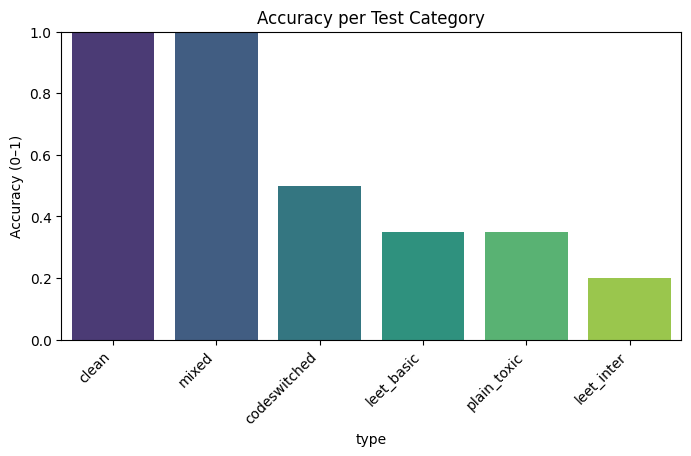

In [5]:
# =============================================================================
# Accuracy Summary
# =============================================================================
correct = (df_results["Detected"] == df_results["Expected"]).sum()
total = len(df_results)
accuracy = correct / total * 100

print(f"Pipeline detected {correct}/{total} messages correctly ({accuracy:.2f}%)")

# Add per-category accuracy barplot using seaborn
df_results["Correct"] = df_results["Detected"] == df_results["Expected"]
cat_acc = (
    pd.DataFrame(test_cases)
    .assign(Correct=df_results["Correct"])
    .groupby("type")["Correct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=cat_acc.index, y=cat_acc.values, hue=cat_acc.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.title("Accuracy per Test Category")
plt.ylabel("Accuracy (0–1)")
plt.ylim(0, 1)
plt.show()

### ⚙️ Benchmark Results Preview

,Test_ID,Message_Type,Is_Toxic,Approach,Time_us,Memory_KB
0,1,plain_toxic,True,Boyer–Moore,1077.6,1.779297
1,1,plain_toxic,True,Aho–Corasick,223.5,12.951172
2,1,plain_toxic,True,Hybrid,578.0,1.646484
3,2,plain_toxic,True,Boyer–Moore,452.9,1.626953
4,2,plain_toxic,True,Aho–Corasick,183.8,9.826172


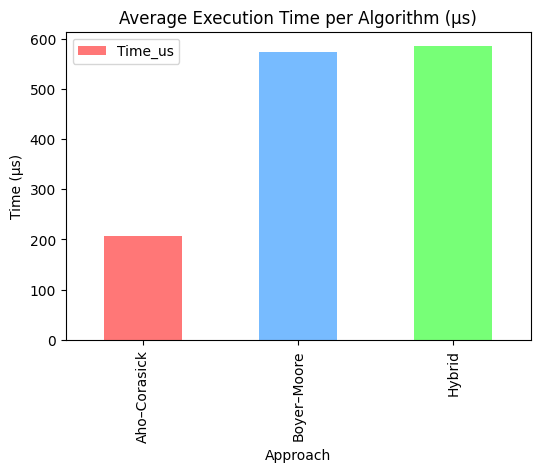

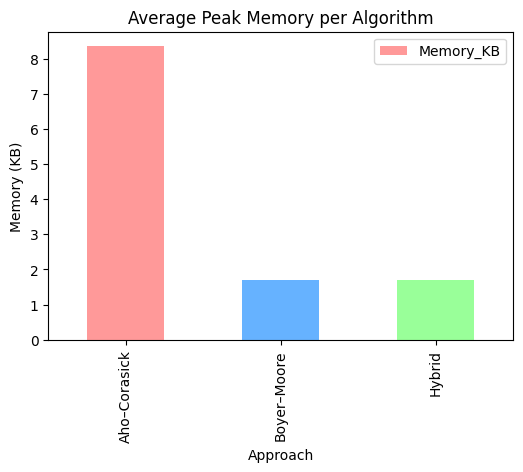

In [6]:
# =============================================================================
# Benchmark Results (Execution Time + Memory)
# =============================================================================
CSV_PATH = "experiments/results/tables/benchmark_results.csv"

if os.path.exists(CSV_PATH):
    bench = pd.read_csv(CSV_PATH)
    display(Markdown("### ⚙️ Benchmark Results Preview"))
    display(bench.head())

    # Compute averages
    avg = (
        bench.groupby("Approach")[["Time_us", "Memory_KB"]]
        .mean()
        .reset_index()
    )

    # --- Time Graph ---
    fig, ax1 = plt.subplots(figsize=(6, 4))
    avg.plot(
        kind="bar",
        x="Approach",
        y="Time_us",
        color=["#FF7777", "#77BBFF", "#77FF77"],
        ax=ax1,
    )
    plt.title("Average Execution Time per Algorithm (µs)")
    plt.ylabel("Time (µs)")
    plt.show()

    # --- Memory Graph ---
    fig, ax2 = plt.subplots(figsize=(6, 4))
    avg.plot(
        kind="bar",
        x="Approach",
        y="Memory_KB",
        color=["#FF9999", "#66B2FF", "#99FF99"],
        ax=ax2,
    )
    plt.title("Average Peak Memory per Algorithm")
    plt.ylabel("Memory (KB)")
    plt.show()
else:
    display(Markdown("⚠️ **No benchmark CSV found.** Run `benchmark.py` first."))

In [7]:
# =============================================================================
# Interactive Message Tester
# =============================================================================
display(Markdown("### 💬 Try your own message"))

def test_message(msg):
    """Interactive test input for toxic message detection."""
    norm_msg = normalize(msg)
    out = pipeline.process(msg)
    
    label = "🔥 **Toxic**" if out["flagged"] else "✅ **Clean**"
    display(Markdown(label))
    
    print(f"Original   : {msg}")
    print(f"Normalized : {norm_msg}")
    
    if out["flagged"]:
        detected = [m["pattern"] for m in out["matches"]]
        print("Detected keywords:", detected)

user_input = input("Enter a message to test: ")
test_message(user_input)

display(Markdown("Notebook completed successfully. ✅"))

### 💬 Try your own message

Enter a message to test:  TNGINA KASI


✅ **Clean**

Original   : TNGINA KASI
Normalized : tngina kasi


Notebook completed successfully. ✅